In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from tensorflow.keras.optimizers import (
    Adam,
    RMSprop
)

import warnings
warnings.filterwarnings("ignore")

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


In [33]:
df = pd.read_csv(
    "dataset/pjm_processed.csv",
    parse_dates=["timestamp"]
)

In [34]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

df = df.sort_values("timestamp")

df = df.reset_index(drop=True)

print(df.shape)
print(df.head())

(145224, 18)
            timestamp   demand  hour  day_of_week  month  day  week  year  \
0 2002-01-08 01:00:00  29445.0     1            1      1    8     2  2002   
1 2002-01-08 02:00:00  28670.0     2            1      1    8     2  2002   
2 2002-01-08 03:00:00  28375.0     3            1      1    8     2  2002   
3 2002-01-08 04:00:00  28542.0     4            1      1    8     2  2002   
4 2002-01-08 05:00:00  29261.0     5            1      1    8     2  2002   

   is_weekend    lag_1   lag_48  lag_168  rolling_mean_24  rolling_mean_168  \
0           0  31187.0  27100.0  30393.0     33452.583333      32519.511905   
1           0  29445.0  26097.0  29265.0     33560.208333      32513.869048   
2           0  28670.0  25793.0  28357.0     33672.458333      32510.327381   
3           0  28375.0  25657.0  27899.0     33786.375000      32510.434524   
4           0  28542.0  25778.0  28057.0     33906.208333      32514.261905   

   rolling_std_24  rolling_std_168    period  lag

In [35]:
df["rolling_mean_24"] = (
    df["demand"]
    .shift(1)
    .rolling(24)
    .mean()
)

df["rolling_std_24"] = (
    df["demand"]
    .shift(1)
    .rolling(24)
    .std()
)

df["rolling_mean_168"] = (
    df["demand"]
    .shift(1)
    .rolling(168)
    .mean()
)

df["rolling_std_168"] = (
    df["demand"]
    .shift(1)
    .rolling(168)
    .std()
)

In [36]:
df = df.dropna().reset_index(drop=True)

In [37]:
print(df.isna().sum().sum())

0


In [38]:
test_size = int(len(df) * 0.20)

test_start = len(df) - test_size

remaining = df.iloc[:test_start]

test = df.iloc[test_start:]

In [39]:
validation_hours = 30 * 24

val_start = len(remaining) - validation_hours

train = remaining.iloc[:val_start]

validation = remaining.iloc[val_start:]

In [40]:
print("Train:", train.shape)
print("Validation:", validation.shape)
print("Test:", test.shape)

Train: (115325, 18)
Validation: (720, 18)
Test: (29011, 18)


In [41]:
print(
    "Train:",
    train["timestamp"].min(),
    "to",
    train["timestamp"].max()
)

print(
    "Validation:",
    validation["timestamp"].min(),
    "to",
    validation["timestamp"].max()
)

print(
    "Test:",
    test["timestamp"].min(),
    "to.",
    test["timestamp"].max()
)

Train: 2002-01-15 01:00:00 to 2015-03-13 05:00:00
Validation: 2015-03-13 06:00:00 to 2015-04-12 05:00:00
Test: 2015-04-12 06:00:00 to. 2018-08-03 00:00:00


In [42]:
features = [
    "demand",
    "lag_1",
    "lag_24",
    "lag_48",
    "lag_168",
    "rolling_mean_24",
    "rolling_std_24",
    "rolling_mean_168",
    "rolling_std_168"
]
target_column = "demand"

In [43]:
feature_scaler = MinMaxScaler()

train_scaled = feature_scaler.fit_transform(
    train[features]
)

validation_scaled = feature_scaler.transform(
    validation[features]
)

test_scaled = feature_scaler.transform(
    test[features]
)

In [44]:
target_scaler = MinMaxScaler()

target_train_scaled = target_scaler.fit_transform(
    train[["demand"]]
)

target_validation_scaled = target_scaler.transform(
    validation[["demand"]]
)

target_test_scaled = target_scaler.transform(
    test[["demand"]]
)

In [45]:
def create_multivariate_sequences(
    X_data,
    y_data,
    input_length=168,
    output_length=24
):

    X = []
    y = []

    for i in range(
        len(X_data) - input_length - output_length + 1
    ):

        X.append(
            X_data[
                i:i + input_length
            ]
        )

        y.append(
            y_data[
                i + input_length:
                i + input_length + output_length
            ]
        )

    return np.array(X), np.array(y)

In [15]:
X_train, y_train = create_multivariate_sequences(
    train_scaled,
    target_train_scaled,
    input_length=168,
    output_length=24
)

In [16]:
y_train = y_train.reshape(
    y_train.shape[0],
    24
)

In [17]:
test_X_input = np.concatenate([
    validation_scaled[-168:],
    test_scaled
])

test_y_input = np.concatenate([
    target_validation_scaled[-168:],
    target_test_scaled
])

In [18]:
X_test, y_test = create_multivariate_sequences(
    test_X_input,
    test_y_input,
    input_length=168,
    output_length=24
)

In [19]:
y_test = y_test.reshape(
    y_test.shape[0],
    24
)

In [20]:
# Validation sequences

val_X_input = np.concatenate([
    train_scaled[-168:],
    validation_scaled
])

val_y_input = np.concatenate([
    target_train_scaled[-168:],
    target_validation_scaled
])

X_val, y_val = create_multivariate_sequences(
    val_X_input,
    val_y_input,
    input_length=168,
    output_length=24
)

y_val = y_val.reshape(
    y_val.shape[0],
    24
)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

X_val: (697, 168, 9)
y_val: (697, 24)


In [46]:
#evaluation func
def evaluate_forecast(y_true, y_pred):

    y_true = y_true.flatten()
    y_pred = y_pred.flatten()

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    mse = mean_squared_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(mse)

    mape = np.mean(
        np.abs(
            (y_true - y_pred) /
            np.where(y_true == 0, 1, y_true)
        )
    ) * 100

    r2 = r2_score(
        y_true,
        y_pred
    )

    bias = np.mean(
        y_pred - y_true
    )

    return mae, mse, rmse, mape, r2, bias

In [47]:
def inverse_target(data):

    original_shape = data.shape

    data = data.reshape(-1, 1)

    data = target_scaler.inverse_transform(
        data
    )

    return data.reshape(original_shape)

In [23]:
def build_LSTM_baseline():

# LSTM
    model = Sequential([
        LSTM(64, input_shape=(168, 9)),
        Dense(24)
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mse"
    )

    return model

In [24]:
#Early_stop
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [25]:
LSTM_features = build_LSTM_baseline()

history_features = LSTM_features.fit(
    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=15,
    batch_size=32,

    callbacks=[
        early_stopping
    ],

    verbose=1
)

Epoch 1/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 72s 20ms/step - loss: 0.0035 - val_loss: 0.0020
Epoch 2/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 72s 20ms/step - loss: 0.0020 - val_loss: 0.0020
Epoch 3/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 71s 20ms/step - loss: 0.0017 - val_loss: 0.0014
Epoch 4/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 70s 20ms/step - loss: 0.0015 - val_loss: 0.0013
Epoch 5/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 71s 20ms/step - loss: 0.0015 - val_loss: 0.0014
Epoch 6/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 71s 20ms/step - loss: 0.0014 - val_loss: 0.0012
Epoch 7/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 74s 21ms/step - loss: 0.0013 - val_loss: 0.0015
Epoch 8/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 71s 20ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 9/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 71s 20ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 10/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 72s 20ms/step - loss: 0.0012 - val_loss: 0.0012
Epoch 11/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 71s 20ms/step - loss: 0.0012 - val_loss: 0.0012
Epoch 12

In [48]:
pred_features = LSTM_features.predict(
    X_test,
    verbose=0
)

In [49]:
pred_features = inverse_target(
    pred_features
)

actual_test = inverse_target(
    y_test
)

In [35]:
metrics = evaluate_forecast(
    actual_test,
    pred_features
)

features_result = {
    "Experiment": "LSTM + Lag + Rolling Features",

    "MAE": metrics[0],

    "MSE": metrics[1],

    "RMSE": metrics[2],

    "MAPE": metrics[3],

    "R2": metrics[4],

    "Bias": metrics[5]
}

features_result

{'Experiment': 'LSTM + Lag + Rolling Features',
 'MAE': 1370.3291897197134,
 'MSE': 3844454.4893709905,
 'RMSE': np.float64(1960.7280508451422),
 'MAPE': np.float64(4.310027172619533),
 'R2': 0.9086659657291656,
 'Bias': np.float64(-37.58650017109271)}

In [36]:
results = []

results.append({
    "Experiment": "Phase 5 Baseline LSTM",

    "MAE": 1364.036036,

    "MSE": 3715291,

    "RMSE": 1927.508982,

    "MAPE": 4.343224,

    "R2": 0.911742,

    "Bias": 331.006106
})

In [37]:
results.append(
    features_result
)

In [38]:
improvement_df = pd.DataFrame(
    results
)

improvement_df

,Experiment,MAE,MSE,RMSE,MAPE,R2,Bias
0,Phase 5 Baseline LSTM,1364.036036,3.715291e+06,1927.508982,4.343224,0.911742,331.006106
1,LSTM + Lag + Rolling Features,1370.329190,3.844454e+06,1960.728051,4.310027,0.908666,-37.586500


In [39]:
baseline_rmse = 1927.508982

current_rmse = features_result["RMSE"]

rmse_improvement = (
    (baseline_rmse - current_rmse)
    / baseline_rmse
) * 100

print(
    f"RMSE Improvement: {rmse_improvement:.2f}%"
)

RMSE Improvement: -1.72%


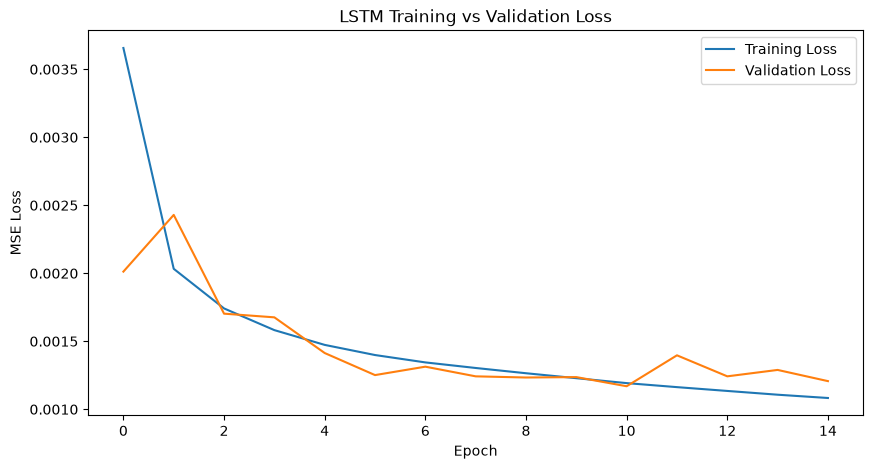

In [40]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_features.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_features.history["val_loss"],
    label="Validation Loss"
)

plt.title(
    "LSTM Training vs Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.legend()

plt.show()

In [41]:
#Build LSTM + Dropout
from tensorflow.keras.layers import Dropout
def build_LSTM_dropout():

    model = Sequential([
        LSTM(
            64,
            input_shape=(168, 9)
        ),

        Dropout(0.2),

        Dense(24)
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mse"
    )

    return model

In [42]:
LSTM_dropout = build_LSTM_dropout()

history_dropout = LSTM_dropout.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 67s 18ms/step - loss: 0.0051 - val_loss: 0.0020
Epoch 2/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 66s 18ms/step - loss: 0.0025 - val_loss: 0.0022
Epoch 3/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 67s 19ms/step - loss: 0.0022 - val_loss: 0.0019
Epoch 4/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 66s 18ms/step - loss: 0.0020 - val_loss: 0.0017
Epoch 5/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 66s 18ms/step - loss: 0.0019 - val_loss: 0.0015
Epoch 6/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 66s 18ms/step - loss: 0.0018 - val_loss: 0.0014
Epoch 7/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 67s 19ms/step - loss: 0.0018 - val_loss: 0.0014
Epoch 8/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 67s 19ms/step - loss: 0.0017 - val_loss: 0.0014
Epoch 9/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 68s 19ms/step - loss: 0.0017 - val_loss: 0.0012
Epoch 10/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 67s 19ms/step - loss: 0.0017 - val_loss: 0.0013
Epoch 11/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 68s 19ms/step - loss: 0.0017 - val_loss: 0.0013
Epoch 12

In [43]:
pred_dropout = LSTM_dropout.predict(
    X_test,
    verbose=0
)

pred_dropout = inverse_target(pred_dropout)

metrics = evaluate_forecast(
    actual_test,
    pred_dropout
)

dropout_result = {
    "Experiment": "LSTM + Lag + Rolling + Dropout",
    "MAE": metrics[0],
    "MSE": metrics[1],
    "RMSE": metrics[2],
    "MAPE": metrics[3],
    "R2": metrics[4],
    "Bias": metrics[5]
}

dropout_result

{'Experiment': 'LSTM + Lag + Rolling + Dropout',
 'MAE': 1384.5844260931158,
 'MSE': 3757279.462430163,
 'RMSE': np.float64(1938.3703109649),
 'MAPE': np.float64(4.416179293143993),
 'R2': 0.9107370129792208,
 'Bias': np.float64(146.86976178495914)}

In [44]:
results.append(dropout_result)

improvement_df = pd.DataFrame(results)

improvement_df

,Experiment,MAE,MSE,RMSE,MAPE,R2,Bias
0,Phase 5 Baseline LSTM,1364.036036,3.715291e+06,1927.508982,4.343224,0.911742,331.006106
1,LSTM + Lag + Rolling Features,1370.329190,3.844454e+06,1960.728051,4.310027,0.908666,-37.586500
2,LSTM + Lag + Rolling + Dropout,1384.584426,3.757279e+06,1938.370311,4.416179,0.910737,146.869762


In [45]:
#bATCH nORMALIZATION
from tensorflow.keras.layers import BatchNormalization
def build_LSTM_batchnorm():

    model = Sequential([
        LSTM(
            64,
            input_shape=(168, 9)
        ),

        BatchNormalization(),

        Dense(24)
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mse"
    )

    return model

In [46]:
LSTM_batchnorm = build_LSTM_batchnorm()

history_batchnorm = LSTM_batchnorm.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 68s 19ms/step - loss: 0.0073 - val_loss: 0.0060
Epoch 2/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 483s 134ms/step - loss: 0.0030 - val_loss: 0.0049
Epoch 3/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 67s 19ms/step - loss: 0.0027 - val_loss: 0.0035
Epoch 4/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 67s 19ms/step - loss: 0.0026 - val_loss: 0.0027
Epoch 5/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 67s 19ms/step - loss: 0.0025 - val_loss: 0.0022
Epoch 6/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 67s 19ms/step - loss: 0.0024 - val_loss: 0.0021
Epoch 7/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 67s 19ms/step - loss: 0.0024 - val_loss: 0.0025
Epoch 8/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 67s 19ms/step - loss: 0.0023 - val_loss: 0.0018
Epoch 9/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 67s 18ms/step - loss: 0.0022 - val_loss: 0.0017
Epoch 10/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 67s 19ms/step - loss: 0.0021 - val_loss: 0.0017
Epoch 11/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 68s 19ms/step - loss: 0.0020 - val_loss: 0.0015
Epoch 

In [47]:
pred_batchnorm = LSTM_batchnorm.predict(
    X_test,
    verbose=0
)

pred_batchnorm = inverse_target(pred_batchnorm)

metrics = evaluate_forecast(
    actual_test,
    pred_batchnorm
)

batchnorm_result = {
    "Experiment": "LSTM + Lag + Rolling + BatchNorm",
    "MAE": metrics[0],
    "MSE": metrics[1],
    "RMSE": metrics[2],
    "MAPE": metrics[3],
    "R2": metrics[4],
    "Bias": metrics[5]
}

batchnorm_result

{'Experiment': 'LSTM + Lag + Rolling + BatchNorm',
 'MAE': 1422.6549205559825,
 'MSE': 4089839.725446964,
 'RMSE': np.float64(2022.3352158944779),
 'MAPE': np.float64(4.512974415545544),
 'R2': 0.9028362638499305,
 'Bias': np.float64(341.8215171786242)}

In [48]:
results.append(batchnorm_result)

improvement_df = pd.DataFrame(results)

improvement_df

,Experiment,MAE,MSE,RMSE,MAPE,R2,Bias
0,Phase 5 Baseline LSTM,1364.036036,3.715291e+06,1927.508982,4.343224,0.911742,331.006106
1,LSTM + Lag + Rolling Features,1370.329190,3.844454e+06,1960.728051,4.310027,0.908666,-37.586500
2,LSTM + Lag + Rolling + Dropout,1384.584426,3.757279e+06,1938.370311,4.416179,0.910737,146.869762
3,LSTM + Lag + Rolling + BatchNorm,1422.654921,4.089840e+06,2022.335216,4.512974,0.902836,341.821517


In [49]:
#Build LSTM with RMSprop
def build_LSTM_rmsprop():

    model = Sequential([
        LSTM(
            64,
            input_shape=(168, 9)
        ),
        BatchNormalization(),
        Dense(24)
    ])

    model.compile(
        optimizer=RMSprop(learning_rate=0.001),
        loss="mse"
    )

    return model

In [50]:
LSTM_rmsprop = build_LSTM_rmsprop()

history_rmsprop = LSTM_rmsprop.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 68s 19ms/step - loss: 0.0066 - val_loss: 0.0053
Epoch 2/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 67s 19ms/step - loss: 0.0031 - val_loss: 0.0032
Epoch 3/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 67s 19ms/step - loss: 0.0029 - val_loss: 0.0052
Epoch 4/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 67s 19ms/step - loss: 0.0028 - val_loss: 0.0030
Epoch 5/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 71s 20ms/step - loss: 0.0027 - val_loss: 0.0023
Epoch 6/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 67s 19ms/step - loss: 0.0027 - val_loss: 0.0025
Epoch 7/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 67s 19ms/step - loss: 0.0026 - val_loss: 0.0024
Epoch 8/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 67s 19ms/step - loss: 0.0026 - val_loss: 0.0023
Epoch 9/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 67s 19ms/step - loss: 0.0025 - val_loss: 0.0021
Epoch 10/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 69s 19ms/step - loss: 0.0025 - val_loss: 0.0024
Epoch 11/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 68s 19ms/step - loss: 0.0025 - val_loss: 0.0020
Epoch 12

In [51]:
pred_rmsprop = LSTM_rmsprop.predict(
    X_test,
    verbose=0
)

pred_rmsprop = inverse_target(pred_rmsprop)

metrics = evaluate_forecast(
    actual_test,
    pred_rmsprop
)

rmsprop_result = {
    "Experiment": "LSTM + Features + BatchNorm + RMSprop",
    "MAE": metrics[0],
    "MSE": metrics[1],
    "RMSE": metrics[2],
    "MAPE": metrics[3],
    "R2": metrics[4],
    "Bias": metrics[5]
}

rmsprop_result

{'Experiment': 'LSTM + Features + BatchNorm + RMSprop',
 'MAE': 1726.4826920554387,
 'MSE': 5534568.124514845,
 'RMSE': np.float64(2352.5662848291536),
 'MAPE': np.float64(5.4415453763282065),
 'R2': 0.8685133518536168,
 'Bias': np.float64(-667.3256087084055)}

In [52]:
results.append(rmsprop_result)

improvement_df = pd.DataFrame(results)

improvement_df

,Experiment,MAE,MSE,RMSE,MAPE,R2,Bias
0,Phase 5 Baseline LSTM,1364.036036,3.715291e+06,1927.508982,4.343224,0.911742,331.006106
1,LSTM + Lag + Rolling Features,1370.329190,3.844454e+06,1960.728051,4.310027,0.908666,-37.586500
2,LSTM + Lag + Rolling + Dropout,1384.584426,3.757279e+06,1938.370311,4.416179,0.910737,146.869762
3,LSTM + Lag + Rolling + BatchNorm,1422.654921,4.089840e+06,2022.335216,4.512974,0.902836,341.821517
4,LSTM + Features + BatchNorm + RMSprop,1726.482692,5.534568e+06,2352.566285,5.441545,0.868513,-667.325609


In [29]:
#LEARING RATE 
from tensorflow.keras.callbacks import ReduceLROnPlateau
lr_scheduler = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

In [54]:
def build_LSTM_scheduler():

    model = Sequential([
        LSTM(
            64,
            input_shape=(168, 9)
        ),
        BatchNormalization(),
        Dense(24)
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mse"
    )

    return model

In [56]:
LSTM_scheduler = build_LSTM_scheduler()

history_scheduler = LSTM_scheduler.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=64,
    callbacks=[
        early_stopping,
        lr_scheduler
    ],
    verbose=1
)

Epoch 1/15
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 52s 28ms/step - loss: 0.0105 - val_loss: 0.0086 - learning_rate: 0.0010
Epoch 2/15
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 51s 28ms/step - loss: 0.0028 - val_loss: 0.0051 - learning_rate: 0.0010
Epoch 3/15
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 51s 28ms/step - loss: 0.0026 - val_loss: 0.0045 - learning_rate: 0.0010
Epoch 4/15
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 51s 28ms/step - loss: 0.0025 - val_loss: 0.0040 - learning_rate: 0.0010
Epoch 5/15
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 52s 29ms/step - loss: 0.0024 - val_loss: 0.0036 - learning_rate: 0.0010
Epoch 6/15
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 51s 28ms/step - loss: 0.0023 - val_loss: 0.0031 - learning_rate: 0.0010
Epoch 7/15
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 51s 28ms/step - loss: 0.0023 - val_loss: 0.0031 - learning_rate: 0.0010
Epoch 8/15
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 51s 28ms/step - loss: 0.0022 - val_loss: 0.0035 - learning_rate: 0.0010
Epoch 9/15
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 51s 28ms/step - loss: 0.0022 - val_loss: 0.002

In [63]:
pred_scheduler = LSTM_scheduler.predict(
    X_test,
    verbose=0
)

pred_scheduler = inverse_target(pred_scheduler)

metrics = evaluate_forecast(
    actual_test,
    pred_scheduler
)

scheduler_result = {
    "Experiment": "LSTM + Features + BatchNorm + LR Scheduler",
    "MAE": metrics[0],
    "MSE": metrics[1],
    "RMSE": metrics[2],
    "MAPE": metrics[3],
    "R2": metrics[4],
    "Bias": metrics[5]
}

scheduler_result

NameError: name 'LSTM_scheduler' is not defined

In [59]:
results.append(scheduler_result)

improvement_df = pd.DataFrame(results)

improvement_df

,Experiment,MAE,MSE,RMSE,MAPE,R2,Bias
0,Phase 5 Baseline LSTM,1364.036036,3.715291e+06,1927.508982,4.343224,0.911742,331.006106
1,LSTM + Lag + Rolling Features,1370.329190,3.844454e+06,1960.728051,4.310027,0.908666,-37.586500
2,LSTM + Lag + Rolling + Dropout,1384.584426,3.757279e+06,1938.370311,4.416179,0.910737,146.869762
3,LSTM + Lag + Rolling + BatchNorm,1422.654921,4.089840e+06,2022.335216,4.512974,0.902836,341.821517
4,LSTM + Features + BatchNorm + RMSprop,1726.482692,5.534568e+06,2352.566285,5.441545,0.868513,-667.325609
5,LSTM + Features + BatchNorm + LR Scheduler,1675.515705,5.270947e+06,2295.854318,5.264510,0.874776,-503.208681


In [ ]:
improvement_df.to_csv(
    "phase6_comparison.csv",
    index=False
)

In [26]:
results=[]


In [27]:
#batch size tune
def build_LSTM_batchsize():

    model = Sequential([
        LSTM(64, input_shape=(168, 9)),
        BatchNormalization(),
        Dense(24)
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mse"
    )

    return model

In [50]:
batch_sizes = [16, 64]

batch_results = []

for batch_size in batch_sizes:

    print(f"\nBatch Size: {batch_size}")

    model = build_LSTM_batchsize()

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=10,
        batch_size=batch_size,
        callbacks=[
            early_stopping,
            lr_scheduler
        ],
        verbose=1
    )

    pred = model.predict(
        X_test,
        verbose=0
    )

    pred = inverse_target(pred)

    metrics = evaluate_forecast(
        actual_test,
        pred
    )

    batch_results.append({
        "Batch Size": batch_size,
        "MAE": metrics[0],
        "MSE": metrics[1],
        "RMSE": metrics[2],
        "MAPE": metrics[3],
        "R2": metrics[4],
        "Bias": metrics[5]
    })


Batch Size: 16
Epoch 1/10
7196/7196 ━━━━━━━━━━━━━━━━━━━━ 111s 15ms/step - loss: 0.0058 - val_loss: 0.0059 - learning_rate: 0.0010
Epoch 2/10
7196/7196 ━━━━━━━━━━━━━━━━━━━━ 109s 15ms/step - loss: 0.0034 - val_loss: 0.0040 - learning_rate: 0.0010
Epoch 3/10
7196/7196 ━━━━━━━━━━━━━━━━━━━━ 108s 15ms/step - loss: 0.0032 - val_loss: 0.0035 - learning_rate: 0.0010
Epoch 4/10
7196/7196 ━━━━━━━━━━━━━━━━━━━━ 109s 15ms/step - loss: 0.0030 - val_loss: 0.0026 - learning_rate: 0.0010
Epoch 5/10
7196/7196 ━━━━━━━━━━━━━━━━━━━━ 108s 15ms/step - loss: 0.0029 - val_loss: 0.0017 - learning_rate: 0.0010
Epoch 6/10
7196/7196 ━━━━━━━━━━━━━━━━━━━━ 109s 15ms/step - loss: 0.0029 - val_loss: 0.0018 - learning_rate: 0.0010
Epoch 7/10
7196/7196 ━━━━━━━━━━━━━━━━━━━━ 999s 139ms/step - loss: 0.0027 - val_loss: 0.0018 - learning_rate: 0.0010
Epoch 8/10
7196/7196 ━━━━━━━━━━━━━━━━━━━━ 108s 15ms/step - loss: 0.0026 - val_loss: 0.0014 - learning_rate: 0.0010
Epoch 9/10
7196/7196 ━━━━━━━━━━━━━━━━━━━━ 110s 15ms/step - loss

In [51]:
batch_df = pd.DataFrame(batch_results)

batch_df

,Batch Size,MAE,MSE,RMSE,MAPE,R2,Bias
0,16,1419.825325,3.962725e+06,1990.659396,4.495959,0.905856,53.810710
1,64,1784.414288,5.619049e+06,2370.453382,5.768800,0.866506,30.182007


In [52]:
best_batch = batch_df.loc[
    batch_df["RMSE"].idxmin()
]

best_batch

Batch Size    1.600000e+01
MAE           1.419825e+03
MSE           3.962725e+06
RMSE          1.990659e+03
MAPE          4.495959e+00
R2            9.058562e-01
Bias          5.381071e+01
Name: 0, dtype: float64

In [53]:
best_batch_size = int(
    best_batch["Batch Size"]
)

print("Best Batch Size:", best_batch_size)

Best Batch Size: 16


In [55]:
# Find the best batch size based on minimum RMSE
best_batch = batch_df.loc[
    batch_df["RMSE"].idxmin()
]

# Get the best batch size
best_batch_size = int(best_batch["Batch Size"])

# Store the best batch-size results
best_batch_result = {
    "Experiment": f"Best Batch Size ({best_batch_size})",
    "MAE": best_batch["MAE"],
    "MSE": best_batch["MSE"],
    "RMSE": best_batch["RMSE"],
    "MAPE": best_batch["MAPE"],
    "R2": best_batch["R2"],
    "Bias": best_batch["Bias"]
}

# Add the result to the results list
results.append(best_batch_result)

# Convert results to DataFrame
improvement_df = pd.DataFrame(results)

improvement_df

,Experiment,MAE,MSE,RMSE,MAPE,R2,Bias
0,Best Batch Size (16),1419.825325,3.962725e+06,1990.659396,4.495959,0.905856,53.81071


In [56]:
for i, item in enumerate(results):
    print(i, type(item), item)

0 <class 'dict'> {'Experiment': 'Best Batch Size (16)', 'MAE': np.float64(1419.8253246089978), 'MSE': np.float64(3962724.8319593095), 'RMSE': np.float64(1990.6593962703187), 'MAPE': np.float64(4.4959592365666285), 'R2': np.float64(0.9058561763161161), 'Bias': np.float64(53.81071038779337)}


In [57]:
results

[{'Experiment': 'Best Batch Size (16)',
  'MAE': np.float64(1419.8253246089978),
  'MSE': np.float64(3962724.8319593095),
  'RMSE': np.float64(1990.6593962703187),
  'MAPE': np.float64(4.4959592365666285),
  'R2': np.float64(0.9058561763161161),
  'Bias': np.float64(53.81071038779337)}]

In [58]:
#number of layers
architectures = {
    "LSTM_32": [32],

    "LSTM_128": [128]
}

In [59]:
architecture_results = []

for name, units in architectures.items():

    print(f"\nTraining: {name}")

    model = Sequential()

    for i, unit in enumerate(units):

        model.add(
            LSTM(
                unit,
                return_sequences=(i < len(units) - 1),
                input_shape=(168, 9) if i == 0 else None
            )
        )

    model.add(BatchNormalization())
    model.add(Dense(24))

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mse"
    )

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=15,
        batch_size=best_batch_size,
        callbacks=[
            early_stopping,
            lr_scheduler
        ],
        verbose=1
    )

    print(f"Predicting: {name}")

    pred = model.predict(
        X_test,
        verbose=0
    )

    pred = inverse_target(pred)

    metrics = evaluate_forecast(
        actual_test,
        pred
    )

    architecture_results.append({
        "Architecture": name,
        "MAE": metrics[0],
        "MSE": metrics[1],
        "RMSE": metrics[2],
        "MAPE": metrics[3],
        "R2": metrics[4],
        "Bias": metrics[5]
    })

    print(f"Finished: {name}")


Training: LSTM_32
Epoch 1/15
7196/7196 ━━━━━━━━━━━━━━━━━━━━ 77s 11ms/step - loss: 0.0080 - val_loss: 0.0050 - learning_rate: 0.0010
Epoch 2/15
7196/7196 ━━━━━━━━━━━━━━━━━━━━ 74s 10ms/step - loss: 0.0035 - val_loss: 0.0041 - learning_rate: 0.0010
Epoch 3/15
7196/7196 ━━━━━━━━━━━━━━━━━━━━ 75s 10ms/step - loss: 0.0032 - val_loss: 0.0034 - learning_rate: 0.0010
Epoch 4/15
7196/7196 ━━━━━━━━━━━━━━━━━━━━ 74s 10ms/step - loss: 0.0031 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 5/15
7196/7196 ━━━━━━━━━━━━━━━━━━━━ 75s 10ms/step - loss: 0.0030 - val_loss: 0.0027 - learning_rate: 0.0010
Epoch 6/15
7196/7196 ━━━━━━━━━━━━━━━━━━━━ 75s 10ms/step - loss: 0.0029 - val_loss: 0.0020 - learning_rate: 0.0010
Epoch 7/15
7196/7196 ━━━━━━━━━━━━━━━━━━━━ 75s 10ms/step - loss: 0.0029 - val_loss: 0.0020 - learning_rate: 0.0010
Epoch 8/15
7196/7196 ━━━━━━━━━━━━━━━━━━━━ 74s 10ms/step - loss: 0.0029 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 9/15
7196/7196 ━━━━━━━━━━━━━━━━━━━━ 75s 10ms/step - loss: 0.002

In [60]:
architecture_df = pd.DataFrame(
    architecture_results
)

architecture_df

,Architecture,MAE,MSE,RMSE,MAPE,R2,Bias
0,LSTM_32,1396.584788,3.895788e+06,1973.775127,4.412821,0.907446,-16.735043
1,LSTM_128,1325.282304,3.655743e+06,1911.999662,4.182159,0.913149,125.509581


In [61]:
best_architecture = architecture_df.loc[
    architecture_df["RMSE"].idxmin()
]

best_architecture

Architecture          LSTM_128
MAE                1325.282304
MSE             3655742.709149
RMSE               1911.999662
MAPE                  4.182159
R2                    0.913149
Bias                125.509581
Name: 1, dtype: object

In [62]:
results.append(scheduler_result)

improvement_df = pd.DataFrame(architecture_results)

improvement_df

NameError: name 'scheduler_result' is not defined

In [64]:
best_arch = architecture_df.loc[
    architecture_df["RMSE"].idxmin()
]

architecture_result = {
    "Experiment": f"Architecture ({best_arch['Architecture']})",
    "MAE": best_arch["MAE"],
    "MSE": best_arch["MSE"],
    "RMSE": best_arch["RMSE"],
    "MAPE": best_arch["MAPE"],
    "R2": best_arch["R2"],
    "Bias": best_arch["Bias"]
}

results.append(architecture_result)

In [65]:

improvement_df = pd.DataFrame(results)

improvement_df

,Experiment,MAE,MSE,RMSE,MAPE,R2,Bias
0,Best Batch Size (16),1419.825325,3.962725e+06,1990.659396,4.495959,0.905856,53.810710
1,Architecture (LSTM_128),1325.282304,3.655743e+06,1911.999662,4.182159,0.913149,125.509581


In [66]:
import keras_tuner as kt

In [67]:
def build_tuned_LSTM(hp):

    model = Sequential()

    model.add(
        LSTM(
            units=hp.Choice(
                "LSTM_units",
                [32, 64, 128]
            ),
            input_shape=(168, 9)
        )
    )

    model.add(
        Dropout(
            hp.Float(
                "dropout",
                0.1,
                0.4,
                step=0.1
            )
        )
    )

    model.add(Dense(24))

    optimizer_name = hp.Choice(
        "optimizer",
        ["adam", "rmsprop"]
    )

    learning_rate = hp.Choice(
        "learning_rate",
        [0.001, 0.0005, 0.0001]
    )

    if optimizer_name == "adam":
        optimizer = Adam(
            learning_rate=learning_rate
        )
    else:
        optimizer = RMSprop(
            learning_rate=learning_rate
        )

    model.compile(
        optimizer=optimizer,
        loss="mse"
    )

    return model

In [68]:
tuner = kt.RandomSearch(
    build_tuned_LSTM,

    objective="val_loss",

    max_trials=3,

    directory="phase6_tuning",

    project_name="LSTM_forecasting",

    overwrite=True
)

In [69]:
tuner.search(
    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=15,

    batch_size=best_batch_size,

    callbacks=[
        early_stopping
    ],

    verbose=1
)

Trial 3 Complete [00h 29m 12s]
val_loss: 0.0016416884027421474

Best val_loss So Far: 0.0012308270670473576
Total elapsed time: 01h 48m 58s


In [70]:
best_hp = tuner.get_best_hyperparameters(
    num_trials=1
)[0]

print(
    "LSTM Units:",
    best_hp.get("LSTM_units")
)

print(
    "Dropout:",
    best_hp.get("dropout")
)

print(
    "Optimizer:",
    best_hp.get("optimizer")
)

print(
    "Learning Rate:",
    best_hp.get("learning_rate")
)

LSTM Units: 64
Dropout: 0.2
Optimizer: adam
Learning Rate: 0.0005


In [71]:
best_model = tuner.get_best_models(
    num_models=1
)[0]

In [72]:
pred_tuned = best_model.predict(
    X_test,
    verbose=0
)

pred_tuned = inverse_target(
    pred_tuned
)

metrics = evaluate_forecast(
    actual_test,
    pred_tuned
)

tuned_result = {
    "Experiment": "LSTM Hyperparameter Tuning",
    "MAE": metrics[0],
    "MSE": metrics[1],
    "RMSE": metrics[2],
    "MAPE": metrics[3],
    "R2": metrics[4],
    "Bias": metrics[5]
}

tuned_result

{'Experiment': 'LSTM Hyperparameter Tuning',
 'MAE': 1362.3093520165762,
 'MSE': 3689818.3410234796,
 'RMSE': np.float64(1920.8899867049856),
 'MAPE': np.float64(4.340181039144044),
 'R2': 0.9123397101607175,
 'Bias': np.float64(120.83591968439347)}

In [73]:
results.append(tuned_result)

final_results = pd.DataFrame(results)

final_results

,Experiment,MAE,MSE,RMSE,MAPE,R2,Bias
0,Best Batch Size (16),1419.825325,3.962725e+06,1990.659396,4.495959,0.905856,53.810710
1,Architecture (LSTM_128),1325.282304,3.655743e+06,1911.999662,4.182159,0.913149,125.509581
2,LSTM Hyperparameter Tuning,1362.309352,3.689818e+06,1920.889987,4.340181,0.912340,120.835920


In [74]:
final_results = pd.DataFrame(results)

final_results.sort_values(
    "RMSE"
)

,Experiment,MAE,MSE,RMSE,MAPE,R2,Bias
1,Architecture (LSTM_128),1325.282304,3.655743e+06,1911.999662,4.182159,0.913149,125.509581
2,LSTM Hyperparameter Tuning,1362.309352,3.689818e+06,1920.889987,4.340181,0.912340,120.835920
0,Best Batch Size (16),1419.825325,3.962725e+06,1990.659396,4.495959,0.905856,53.810710


In [75]:
best_result = final_results.loc[
    final_results["RMSE"].idxmin()
]

best_result

Experiment    Architecture (LSTM_128)
MAE                       1325.282304
MSE                    3655742.709149
RMSE                      1911.999662
MAPE                         4.182159
R2                           0.913149
Bias                       125.509581
Name: 1, dtype: object

In [76]:
best_rmse = best_result["RMSE"]
best_mae = best_result["MAE"]
best_mape = best_result["MAPE"]
best_r2 = best_result["R2"]

In [77]:
baseline_rmse = 1927.508982
baseline_mae = 1364.036036
baseline_mape = 4.343224
baseline_r2 = 0.911742

In [78]:
rmse_improvement = (
    (baseline_rmse - best_rmse)
    / baseline_rmse
) * 100

print(f"RMSE Improvement: {rmse_improvement:.2f}%")

RMSE Improvement: 0.80%


In [79]:
comparison = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "MAPE",
        "R2"
    ],

    "Phase 5 Baseline": [
        baseline_mae,
        baseline_rmse,
        baseline_mape,
        baseline_r2
    ],

    "Phase 6 Final": [
        best_mae,
        best_rmse,
        best_mape,
        best_r2
    ]
})

comparison

,Metric,Phase 5 Baseline,Phase 6 Final
0,MAE,1364.036036,1325.282304
1,RMSE,1927.508982,1911.999662
2,MAPE,4.343224,4.182159
3,R2,0.911742,0.913149


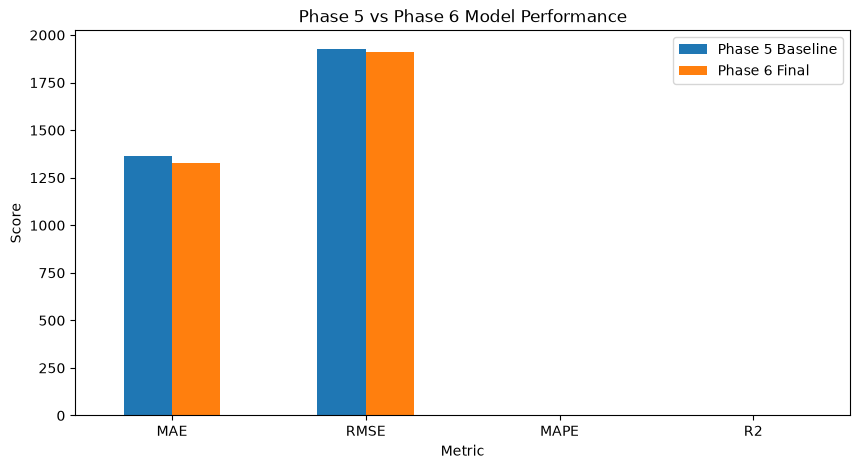

In [80]:
comparison.set_index("Metric").plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Phase 5 vs Phase 6 Model Performance")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

In [81]:
best_model.save(
    "final_LSTM_forecasting_model.keras"
)

In [ ]:
import pandas as pd

# Final LSTM model comparison results
results = [
    {
        "Experiment": "Baseline LSTM",
        
        "MAE": 1364.036036,
        "MSE": 3715291,
        "RMSE": 1927.508982,
        "MAPE": 4.343224,
        "R2": 0.911742,
        "Bias": 166.869762
    },
    {
        "Experiment": "LSTM + Lag + Rolling Features",
        
        "MAE": 1370.329190,
        "MSE": 3844454,
        "RMSE": 1960.728051,
        "MAPE": 4.310027,
        "R2": 0.908666,
        "Bias": -37.586500
    },
    {
        "Experiment": "LSTM + Lag + Rolling + Dropout",
        
        "MAE": 1384.584426,
        "MSE": 3757279,
        "RMSE": 1938.370311,
        "MAPE": 4.416179,
        "R2": 0.910737,
        "Bias": 146.869762
    },
    {
        "Experiment": "LSTM + Lag + Rolling + BatchNorm",
        
        "MAE": 1422.654921,
        "MSE": 4089840,
        "RMSE": 2022.335216,
        "MAPE": 4.512974,
        "R2": 0.902836,
        "Bias": 341.821517
    },
    {
        "Experiment": "LSTM + Features + BatchNorm + RMSprop",
        
        "MAE": 1726.482692,
        "MSE": 5534568,
        "RMSE": 2352.566285,
        "MAPE": 5.441545,
        "R2": 0.868513,
        "Bias": -667.325609
    },
    {
        "Experiment": "LSTM + Features + BatchNorm + LR Scheduler",
        
        "MAE": 1675.515705,
        "MSE": 5270947,
        "RMSE": 2295.854318,
        "MAPE": 5.264510,
        "R2": 0.874776,
        "Bias": -503.208681
    },
    {
        "Experiment": "LSTM_128",
       
        "MAE": 1325.282304,
        "MSE": 3655743,
        "RMSE": 1911.999662,
        "MAPE": 4.182159,
        "R2": 0.913149,
        "Bias": 125.509581
    },
    {
        "Experiment": "LSTM + Batch Size 16",
        
        "MAE": 1419.825325,
        "MSE": 3962725,
        "RMSE": 1990.659396,
        "MAPE": 4.495959,
        "R2": 0.905856,
        "Bias": 53.810710
    }
]

# Create DataFrame
final_df = pd.DataFrame(results)

# Sort by RMSE (best → worst)
final_df = final_df.sort_values("RMSE", ascending=True).reset_index(drop=True)

# Add ranking
final_df.insert(0, "Rank", range(1, len(final_df) + 1))

# Display
print(final_df)

# Save CSV
final_df.to_csv("final_lstm_comparison.csv", index=False)

print("\nCSV created: final_lstm_comparison.csv")

In [82]:
final_results.to_csv(
    "phase6_model_improvement_results.csv",
    index=False
)

In [83]:
comparison.to_csv(
    "phase5_vs_phase6_comparison.csv",
    index=False
)

In [ ]:
phase6_model_improvement_results_GRU